<a href="https://colab.research.google.com/github/Yashchaure2006/Data_Science_Lab/blob/main/exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== FIRST 5 ROWS ====


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



===== DATASET INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

===== STATISTICAL SUMMARY ====


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



===== MISSING VALUES ====
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

===== DATA AFTER CLEANING AND PREPROCESSING ====


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0



===== MISSING VALUES AFTER CLEANING ====
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


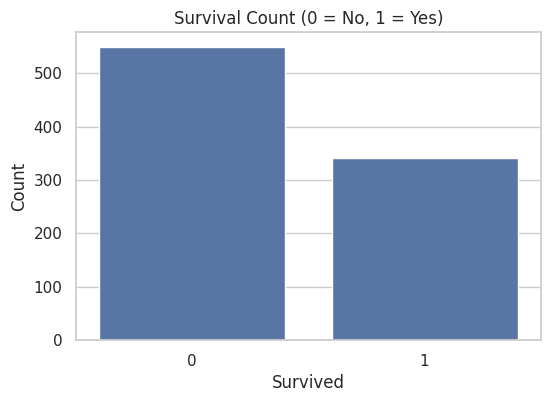

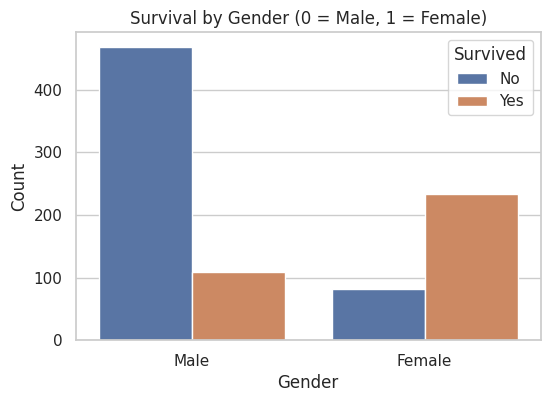

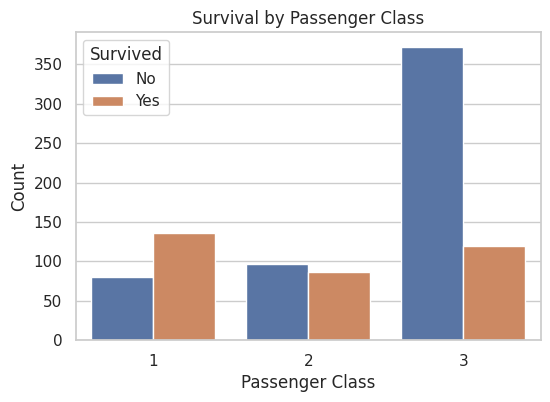

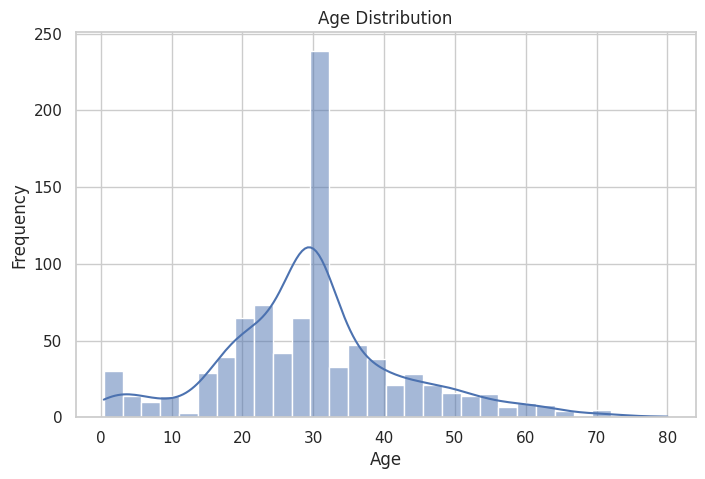


===== SURVIVAL RATE BY GENDER ====
Sex
0    18.89%
1    74.20%
Name: Survived, dtype: object

===== SURVIVAL RATE BY CLASS ====
Pclass
1    62.96%
2    47.28%
3    24.24%
Name: Survived, dtype: object

===== ANALYSIS COMPLETED SUCCESSFULLY ====


In [23]:
# ### Titanic Data Analysis: Loading and Initial Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("===== FIRST 5 ROWS ====")
display(df.head())

print("\n===== DATASET INFO ====")
df.info()

print("\n===== STATISTICAL SUMMARY ====")
display(df.describe())

print("\n===== MISSING VALUES ====")
print(df.isnull().sum())

# ### Data Cleaning and Preprocessing
# Here, we handle missing values by filling the `Age` with its mean, `Embarked` with its most frequent value (mode), and dropping the `Cabin` column due to a high number of missing values. We also convert categorical features (`Sex` and `Embarked`) into numerical representations for analysis.

# Fill missing Age with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked with most frequent value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column due to too many missing values
df = df.drop(columns=['Cabin'])

# Convert categorical variables into numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("\n===== DATA AFTER CLEANING AND PREPROCESSING ====")
display(df.head())

print("\n===== MISSING VALUES AFTER CLEANING ====")
print(df.isnull().sum())

# ### Data Visualization: Exploring Survival Patterns
# These visualizations help us understand the distribution of survival and how it relates to key attributes like gender, passenger class, and age.

# 1. Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# 2. Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender (0 = Male, 1 = Female)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# 3. Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# 4. Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()



# ### Gaining Insights into Survival Patterns
# Finally, let's look at the survival rates based on gender and passenger class to draw some conclusions.

print("\n===== SURVIVAL RATE BY GENDER ====")
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f'{x:.2%}') # Format as percentage
)

print("\n===== SURVIVAL RATE BY CLASS ====")
print(df.groupby('Pclass')['Survived'].mean().apply(lambda x: f'{x:.2%}') # Format as percentage
)

print("\n===== ANALYSIS COMPLETED SUCCESSFULLY ====")